## PCA

linear data 

Best for analysis and it is very clear 

In [8]:
#data 
from sklearn.datasets import load_iris
data = load_iris() 
df = data.data

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA #NOTE
import numpy as np

df = StandardScaler().fit_transform(df)

# Create PCA object (reduce to 2 component)
pca = PCA(n_components=2)

# Fit and transform data
X_pca = pca.fit_transform(df)

print("Transformed Data:\n", X_pca)
print("Explained Variance:", pca.explained_variance_)

Transformed Data:
 [[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]
 [-2.07563095  1.48917752]
 [-2.44402884  0.0476442 ]
 [-2.23284716  0.22314807]
 [-2.33464048 -1.11532768]
 [-2.18432817 -0.46901356]
 [-2.1663101   1.04369065]
 [-2.32613087  0.13307834]
 [-2.2184509  -0.72867617]
 [-2.6331007  -0.96150673]
 [-2.1987406   1.86005711]
 [-2.26221453  2.68628449]
 [-2.2075877   1.48360936]
 [-2.19034951  0.48883832]
 [-1.898572    1.40501879]
 [-2.34336905  1.12784938]
 [-1.914323    0.40885571]
 [-2.20701284  0.92412143]
 [-2.7743447   0.45834367]
 [-1.81866953  0.08555853]
 [-2.22716331  0.13725446]
 [-1.95184633 -0.62561859]
 [-2.05115137  0.24216355]
 [-2.16857717  0.52714953]
 [-2.13956345  0.31321781]
 [-2.26526149 -0.3377319 ]
 [-2.14012214 -0.50454069]
 [-1.83159477  0.42369507]
 [-2.61494794  1.79357586]
 [-2.44617739  2.15072788]
 [-2.10997488 -0.46020184]
 [-2.2078089  -0.2061074 ]
 [-2.0451

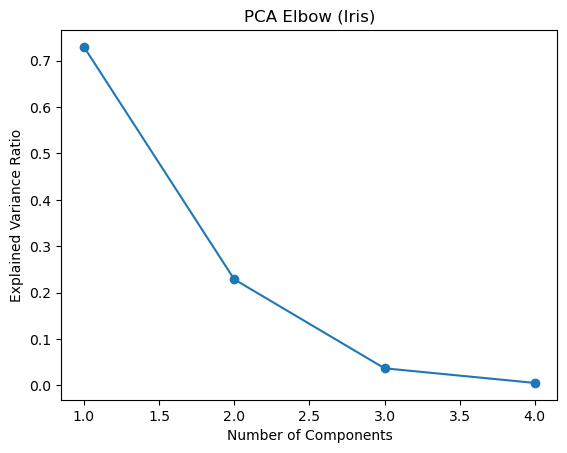

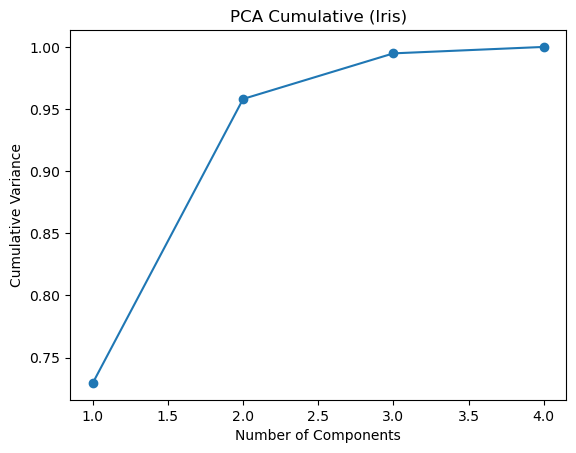

In [3]:

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
# Load dataset
df = StandardScaler().fit_transform(df)

# Apply PCA
pca = PCA()
pca.fit(df )

# Explained variance
variance = pca.explained_variance_ratio_ # --> variance 

cumulative = np.cumsum(variance) # --> cumulative 
###############################################################
# Plot elbow (individual)
plt.plot(range(1, len(variance)+1) , variance, marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Elbow (Iris)")
plt.show()

# Plot cumulative (better)
plt.plot(range(1, len(cumulative)+1) , cumulative, marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA Cumulative (Iris)")
plt.show()

In [ ]:
# so we pick 3 components 

## T-SNE
Non-Linear and more visualization focused 

capture local relations in clusters  and it cant explain variance 

and like best for seeing classes in Ires for exp 

[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 150 samples in 0.003s...
[t-SNE] Computed neighbors for 150 samples in 0.005s...
[t-SNE] Computed conditional probabilities for sample 150 / 150
[t-SNE] Mean sigma: 0.362607
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.047558
[t-SNE] KL divergence after 1000 iterations: 0.298411


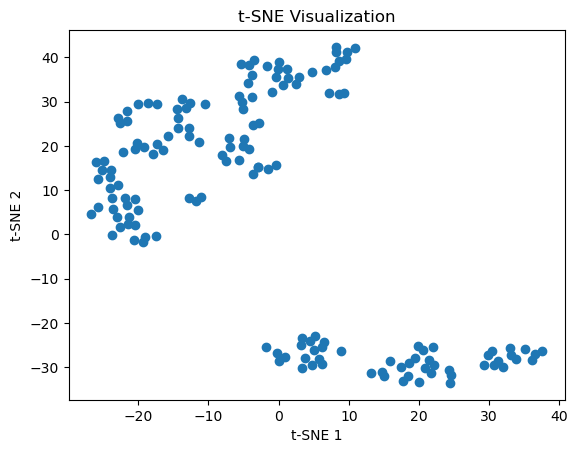

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Apply t-SNE (2 components for visualization)
tsne = TSNE(
    n_components=2,
    perplexity=10,      # same as R
    learning_rate=200,   # eta
    method='barnes_hut',
    angle=0.5,         # similar to theta
    verbose=1,
    random_state=123)

X_tsne = tsne.fit_transform(df)

# Plot
plt.scatter(X_tsne[:, 0], X_tsne[:, 1])
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization")
plt.show()

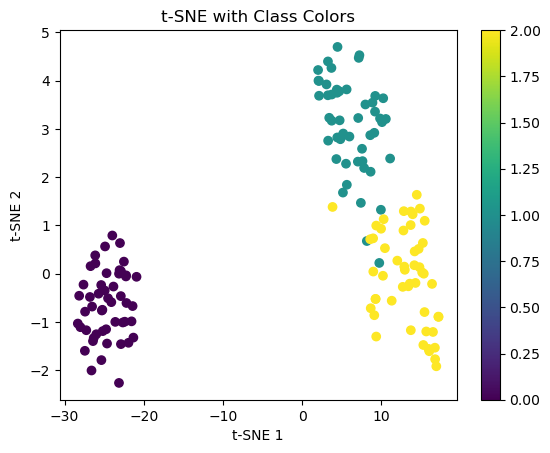

In [22]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(df)

# Plot with colors
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=data.target)
# adding legend 

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE with Class Colors")
plt.colorbar()
plt.show()

## UMAP

basicly a modrn ver of T-SNE and better 

Best for preprocessing and visulization 

/home/bigboss/miniconda3/envs/ml/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


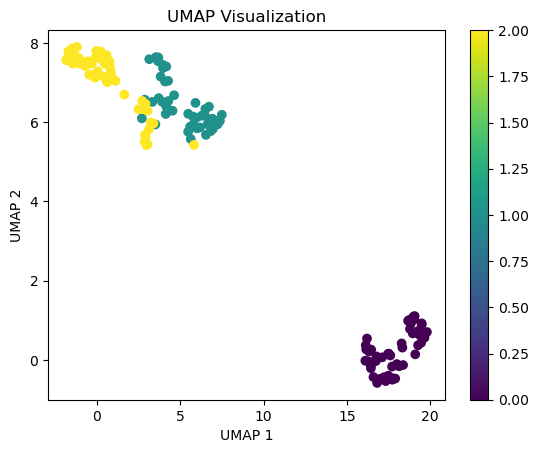

In [3]:
# first do the pip 
#!pip install umap-learn
import umap.umap_ as umap
import matplotlib.pyplot as plt


# Apply UMAP
reducer = umap.UMAP(n_components=2
    
    ,random_state=42)
X_umap = reducer.fit_transform(df)
# Plot
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=data.target)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP Visualization")
plt.colorbar()
plt.show()

/home/bigboss/miniconda3/envs/ml/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


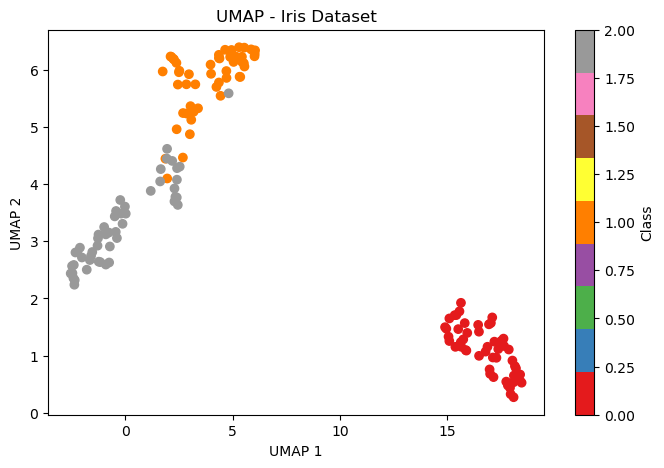

In [10]:
import umap
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load properly
iris = load_iris()
X = iris.data
y = iris.target

# UMAP
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    random_state=123
)

X_umap = reducer.fit_transform(X)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='Set1')

plt.title("UMAP - Iris Dataset")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(label="Class")

plt.show()